# Housing price prediction case study

## Libraries

In [459]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# importing minmaxscaler
from sklearn.preprocessing import MinMaxScaler

# importing onehot encoder
from sklearn.preprocessing import OneHotEncoder

# importing train_test_split function
from sklearn.model_selection import train_test_split

## Read Dataset

In [460]:
filepath = '/content/drive/MyDrive/ICT AI & ML/Data/House_Pricing.csv'
df_house_price = pd.read_csv(filepath)
df_house_price.head(4)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000


## EDA

In [461]:
# Taking Sale Price as target column other columns as feature columns

In [462]:
# checking number of rows and columns
df_house_price.shape

(21613, 21)

In [463]:
# details of variables
df_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [464]:
# summary of numerical variables
df_house_price.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [465]:
# Missing value Analysis
df_house_price.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [466]:
# Looking duplicated rows if
df_house_price.duplicated().sum()

np.int64(0)

In [467]:
df_house_price = df_house_price.drop_duplicates()

In [468]:
# it is dropped because more than 90% of data is missing further imputation will manipulate the data
df_house_price.drop(columns= ['No of Times Visited'],inplace= True)

In [469]:
# droping the rows that have missing values. There is only one missing entry in this columns.
df_house_price.dropna(subset = ['Zipcode','Latitude','Longitude','Living Area after Renovation (in Sqft)','Sale Price'], inplace = True)



Text(0.5, 1.0, 'Histogram of Flat Area (in Sqft)')

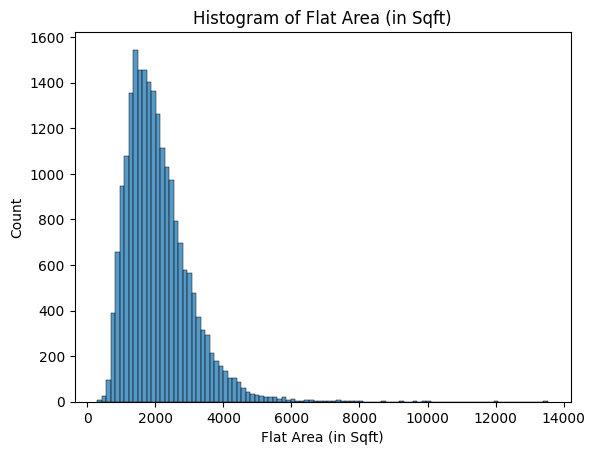

In [470]:
sns.histplot(df_house_price['Flat Area (in Sqft)'],bins =100)
plt.title("Histogram of Flat Area (in Sqft)")

Text(0.5, 1.0, 'Histogram  number of bathrooms')

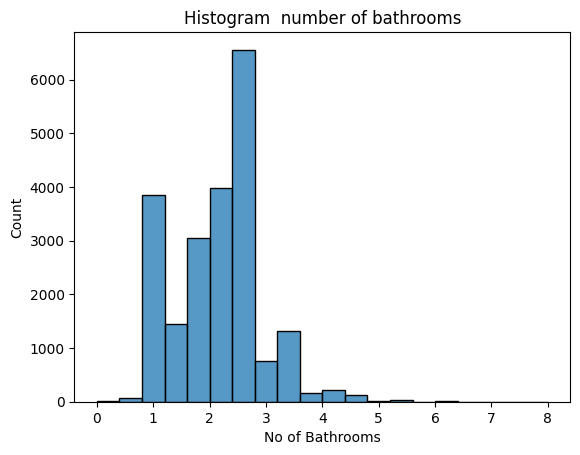

In [471]:
sns.histplot(df_house_price['No of Bathrooms'],bins =20)
plt.title("Histogram  number of bathrooms")

Text(0.5, 1.0, 'Histogram of Lot Area (in Sqft)')

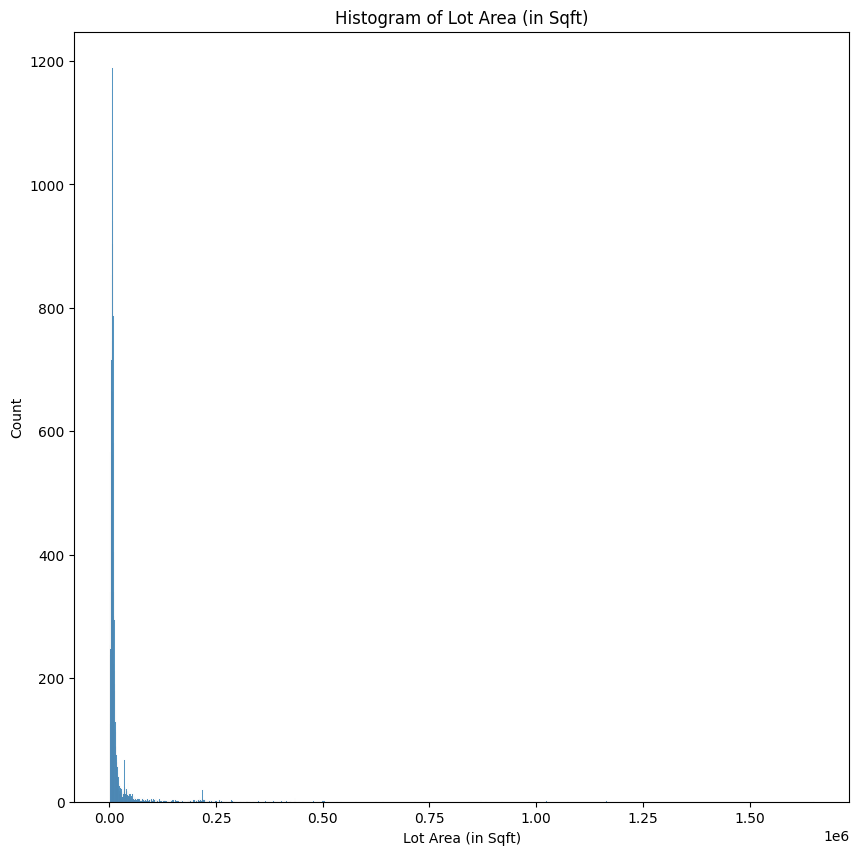

In [431]:
plt.figure(figsize =(10,10))
sns.histplot(df_house_price['Lot Area (in Sqft)'])
plt.title("Histogram of Lot Area (in Sqft)")

Text(0.5, 1.0, 'Histogram of Area of the House from Basement(in Sqft)')

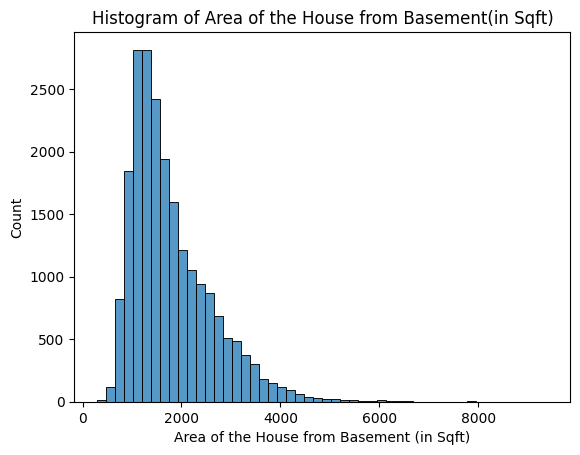

In [432]:
sns.histplot(df_house_price['Area of the House from Basement (in Sqft)'],bins = 50)
plt.title("Histogram of Area of the House from Basement(in Sqft)")

In [433]:
df_house_price['Flat Area (in Sqft)'].fillna(df_house_price['Flat Area (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_4929/1440046811.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Flat Area (in Sqft)'].fillna(df_house_price['Flat Area (in Sqft)'].median(),inplace = True)


In [434]:
df_house_price['Flat Area (in Sqft)'].fillna(df_house_price['Flat Area (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_4929/1440046811.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Flat Area (in Sqft)'].fillna(df_house_price['Flat Area (in Sqft)'].median(),inplace = True)


In [435]:
df_house_price['No of Bathrooms'].fillna(df_house_price['No of Bathrooms'].median(),inplace = True)

/tmp/ipykernel_4929/1112805932.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['No of Bathrooms'].fillna(df_house_price['No of Bathrooms'].median(),inplace = True)


In [436]:
df_house_price['Lot Area (in Sqft)'].fillna(df_house_price['Lot Area (in Sqft)'].median(),inplace = True)


/tmp/ipykernel_4929/1332892500.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Lot Area (in Sqft)'].fillna(df_house_price['Lot Area (in Sqft)'].median(),inplace = True)


In [437]:
df_house_price['Area of the House from Basement (in Sqft)'].fillna(df_house_price['Area of the House from Basement (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_4929/1780526693.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Area of the House from Basement (in Sqft)'].fillna(df_house_price['Area of the House from Basement (in Sqft)'].median(),inplace = True)


In [438]:
df_house_price.isna().sum()
# all missing values have been filled

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


In [439]:
df_house_price['Date House was Sold'] = pd.to_datetime(df_house_price['Date House was Sold'])
# Extract useful features
df_house_price['Sale_Year'] = df_house_price['Date House was Sold'].dt.year
df_house_price['Sale_Month'] = df_house_price['Date House was Sold'].dt.month
# Remove original date column
df_house_price.drop('Date House was Sold', axis=1, inplace=True)

## Outlier Handling

In [440]:
num_cols = []  # for selecting numerical cols
cat_cols = []  # for selecting categorical cols

In [441]:
num_cols = df_house_price.drop(columns= ['ID']).select_dtypes(include = ['int64', 'float64']).columns
num_cols

Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [442]:
cat_cols = df_house_price.select_dtypes(include = ['object','bool'])

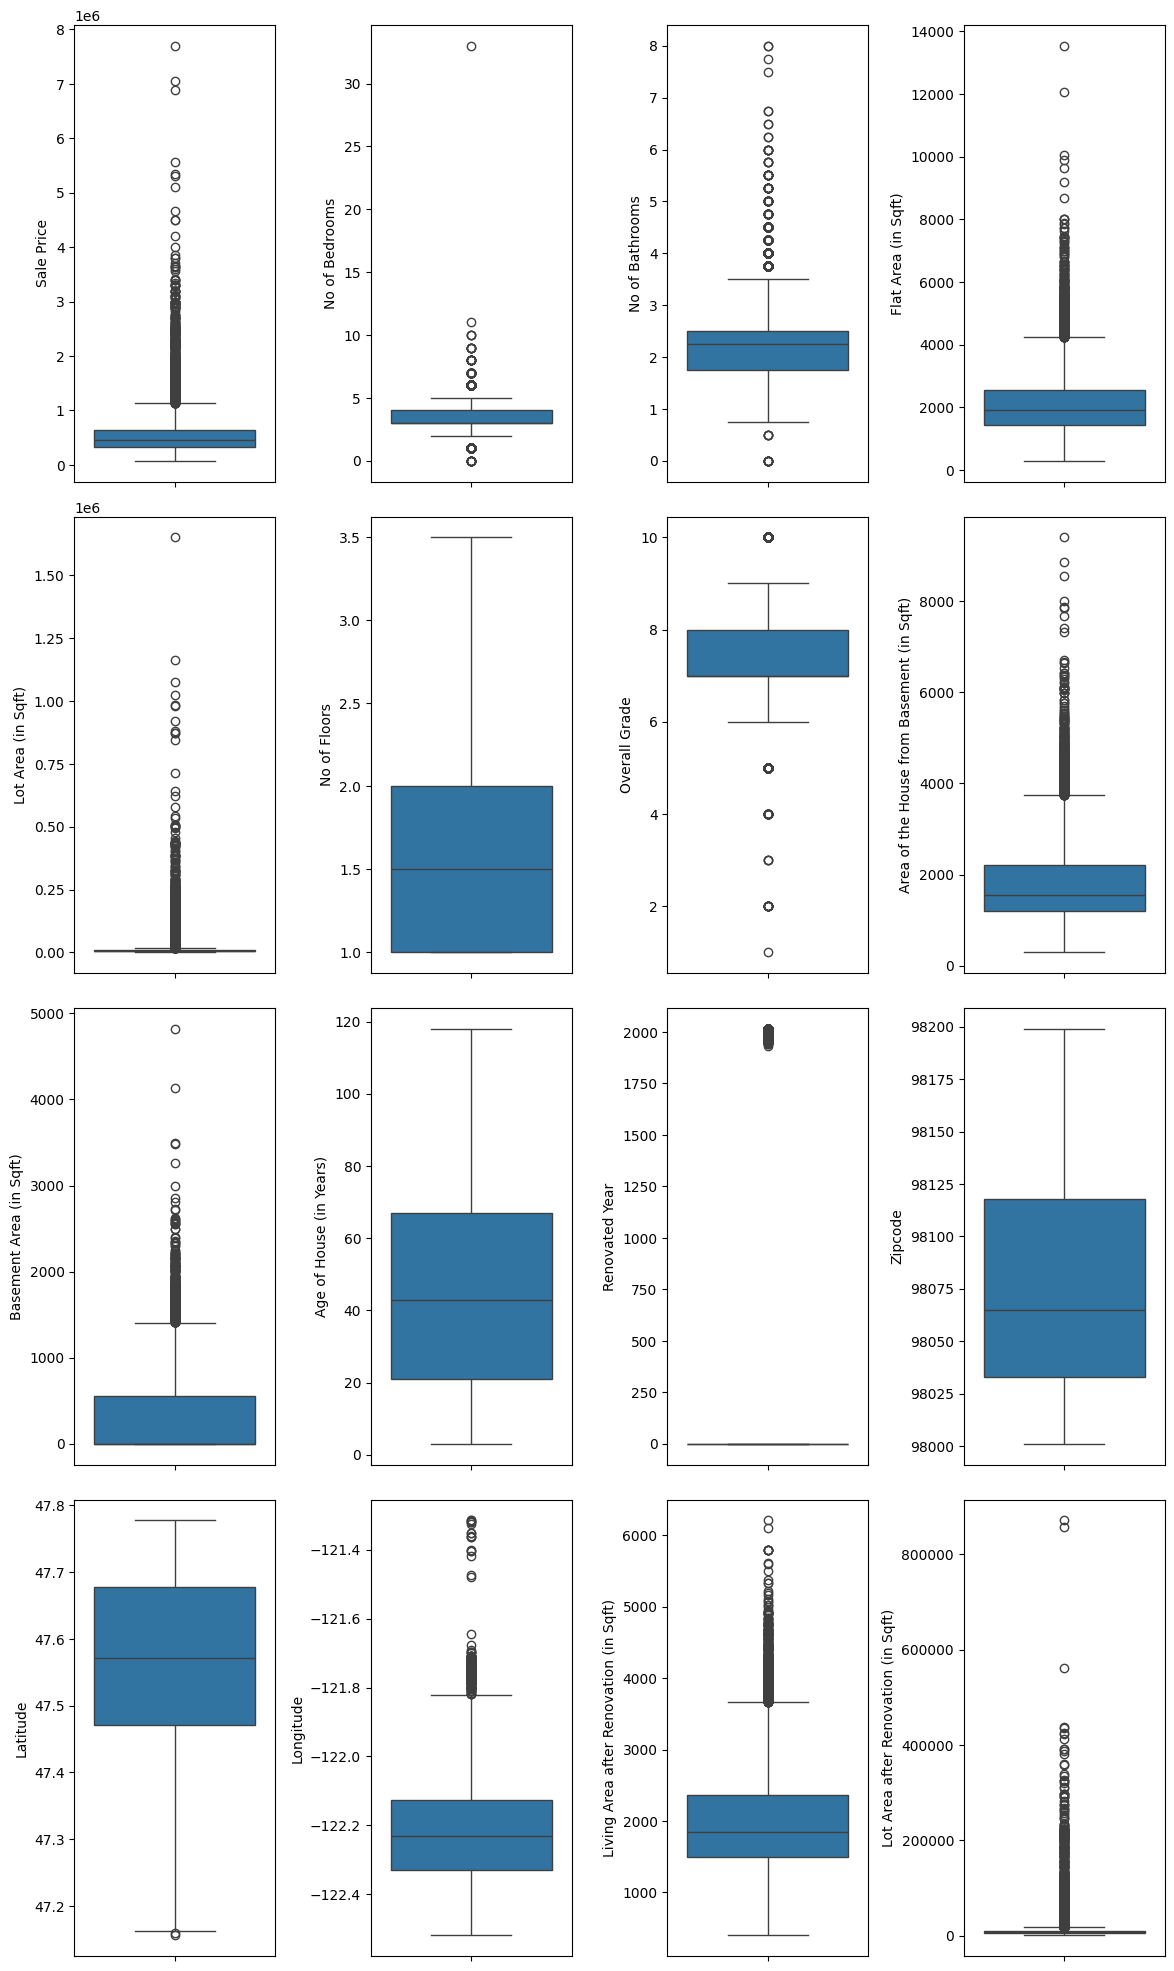

In [443]:
plt.figure(figsize=(12, 20))
for i in range(len(num_cols)):
  plt.subplot(4, 4, i+1)
  plt.tight_layout()
  sns.boxplot(df_house_price[num_cols[i]])

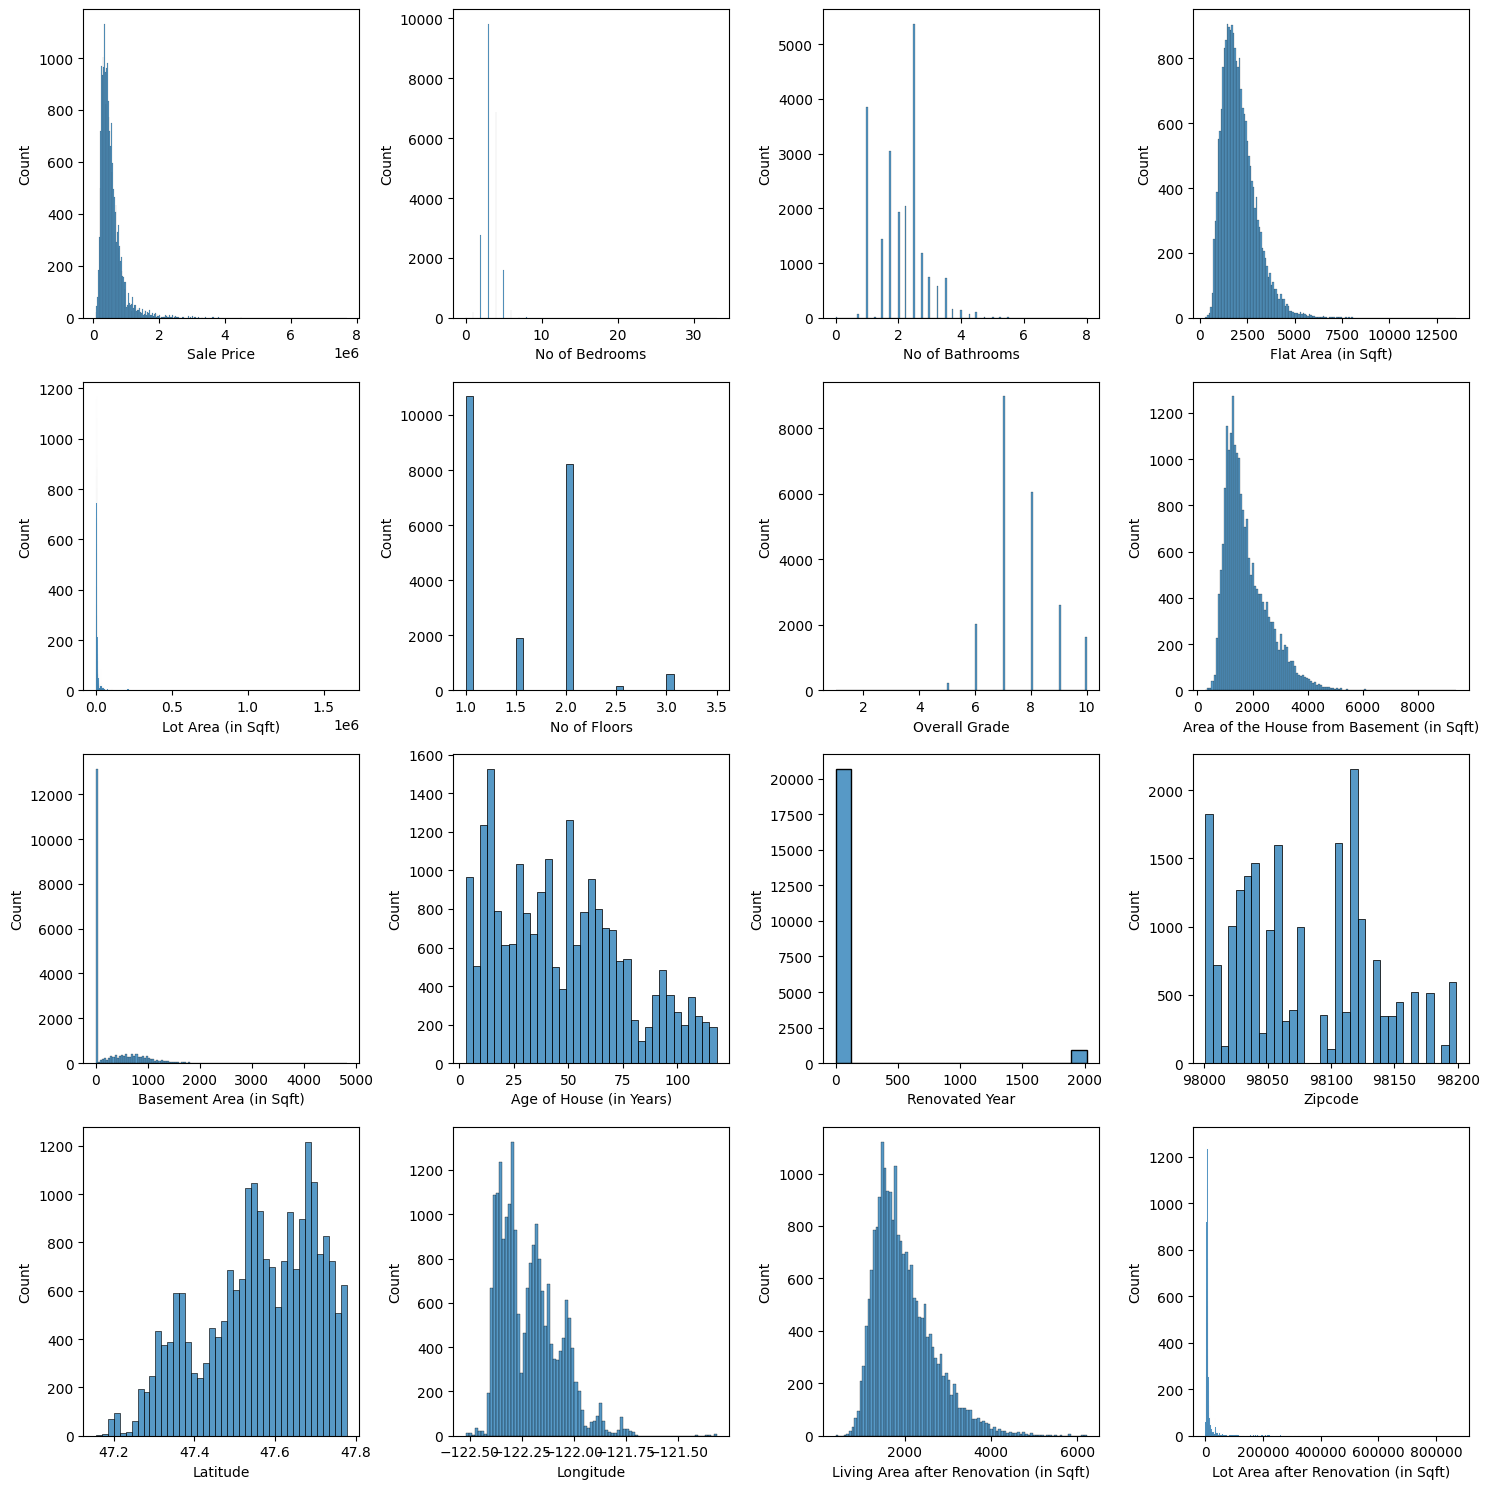

In [444]:
plt.figure(figsize=(15, 15))
for i in range(len(num_cols)):
  plt.subplot(4, 4, i+1)
  plt.tight_layout()
  sns.histplot(df_house_price[num_cols[i]])

In [445]:
#  33 is a outlier  number of bedroom as it is a extreme value from the rest of the values. clipping that to second largest number of bedrooms
bedroom_large  = df_house_price['No of Bedrooms'].nlargest(2).iloc[-1] # calculating second largest
df_house_price['No of Bedrooms'] = df_house_price['No of Bedrooms'].clip(upper = bedroom_large) # clipping by second largest value


In [446]:
#In Flat Area (in Sqft), there is only two columns which are outliers.clipping to both of them to 3rd one

large_flat  = df_house_price['Flat Area (in Sqft)'].nlargest(3).iloc[-2] # calculating third largest value of Flat Area (in Sqft)
df_house_price['Flat Area (in Sqft)'] = df_house_price['Flat Area (in Sqft)'].clip(upper = large_flat) # clipping by third largest value

In [447]:
df_house_price.drop('ID', axis=1, inplace=True)

## Scaling

In [448]:
num_cols  #checking names of num_cols

Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [449]:
# These are not able to do scaling
num_cols = num_cols.drop(['Zipcode'])

In [450]:
# All columns are right skewed, so we can apply minmax scaler for all numerical columns.

In [451]:
num_cols = df_house_price.select_dtypes(include=['int64', 'float64']).columns

# Exclude the target variable
num_cols = num_cols.drop('Sale Price')

minmaxscaler = MinMaxScaler()

df_house_price[num_cols] = minmaxscaler.fit_transform(
    df_house_price[num_cols]
)

In [452]:
cat_cols

,Waterfront View,Condition of the House
0,No,Fair
1,No,Fair
2,No,Fair
3,No,Excellent
4,No,Fair
...,...,...
21608,No,Fair
21609,No,Fair
21610,No,Fair
21611,No,Fair


In [453]:
cat_cols = df_house_price.select_dtypes(include=['object'])

cat_cols = cat_cols.drop(columns=['Date House was Sold'],errors='ignore')


In [454]:
cat_cols.columns

Index(['Waterfront View', 'Condition of the House'], dtype='object')

In [455]:
df_house_price = pd.get_dummies(df_house_price,columns=cat_cols.columns,drop_first=True,dtype=int)

In [456]:
#housing_price.columns.tolist()
y = df_house_price['Sale Price'] # defining target column
X = df_house_price.drop(columns = ['Sale Price']) # defining deture columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [457]:
df_house_price.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),...,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year,Sale_Month,Waterfront View_Yes,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,221900.0,0.272727,0.12500,0.075680,0.003108,0.0,0.666667,0.097588,0.000000,0.521739,...,0.217608,0.161934,0.005742,2017,10,0,0,1,0,0
1,538000.0,0.272727,0.28125,0.193878,0.004072,0.4,0.666667,0.206140,0.082988,0.556522,...,0.166113,0.222165,0.008027,2017,12,0,0,1,0,0
2,180000.0,0.181818,0.12500,0.040816,0.005743,0.0,0.555556,0.052632,0.000000,0.713043,...,0.237542,0.399415,0.008513,2016,2,0,0,1,0,0
3,604000.0,0.363636,0.37500,0.142007,0.002714,0.0,0.666667,0.083333,0.188797,0.434783,...,0.104651,0.165376,0.004996,2017,12,0,1,0,0,0
4,510000.0,0.272727,0.25000,0.118197,0.004579,0.0,0.777778,0.152412,0.000000,0.243478,...,0.393688,0.241094,0.007871,2016,2,0,0,1,0,0


In [458]:
df_house_price.shape

(21605, 23)